In [1]:
import os
import joblib
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(r"D:\machine_learning\ud120-projects\tools"))
from feature_format import featureFormat, targetFeatureSplit

In [2]:
### read in data dictionary, convert to numpy array
data_dict = joblib.load( open(r"D:\machine_learning\ud120-projects\final_project\final_project_dataset.pkl", "rb") )
features = ["salary", "bonus"]
data = featureFormat(data_dict, features)

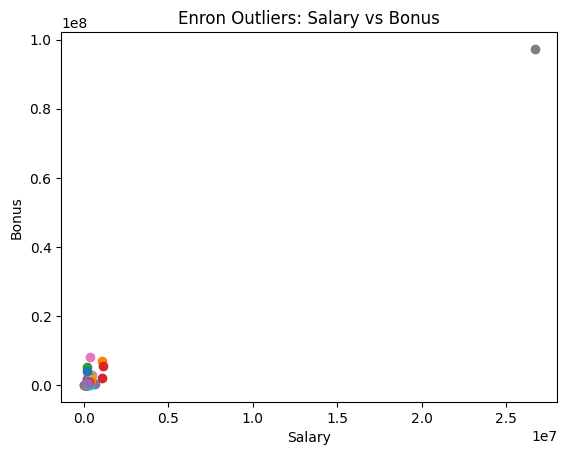

In [3]:
# Scatter plot of salary vs bonus
for point in data:
    salary = point[0]
    bonus = point[1]
    plt.scatter(salary, bonus)

plt.xlabel("Salary")
plt.ylabel("Bonus")
plt.title("Enron Outliers: Salary vs Bonus")
plt.show()

There’s one outlier that should pop out to you immediately. Now the question is to identify the source. We found the original data source to be very helpful for this identification; you can find that PDF in final_project/enron61702insiderpay.pdf

**What’s the name of the dictionary key of this data point?**

 (e.g. if this is Ken Lay, the answer would be “LAY KENNETH L”).

In [4]:
# I will know the outlier by using pandas library
import pandas as pd
df = pd.DataFrame.from_dict(data_dict, orient='index')

In [5]:
import numpy as np

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, METTS MARK to GLISAN JR BEN F
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   salary                     146 non-null    object
 1   to_messages                146 non-null    object
 2   deferral_payments          146 non-null    object
 3   total_payments             146 non-null    object
 4   loan_advances              146 non-null    object
 5   bonus                      146 non-null    object
 6   email_address              146 non-null    object
 7   restricted_stock_deferred  146 non-null    object
 8   deferred_income            146 non-null    object
 9   total_stock_value          146 non-null    object
 10  expenses                   146 non-null    object
 11  from_poi_to_this_person    146 non-null    object
 12  exercised_stock_options    146 non-null    object
 13  from_messages              146 non-null    object

In [7]:
# replace 'NaN' with np.nan for proper numeric conversion
df.replace('NaN', np.nan, inplace=True)

C:\Users\MO 2024\AppData\Local\Temp\ipykernel_7312\184824135.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('NaN', np.nan, inplace=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, METTS MARK to GLISAN JR BEN F
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   salary                     95 non-null     float64
 1   to_messages                86 non-null     float64
 2   deferral_payments          39 non-null     float64
 3   total_payments             125 non-null    float64
 4   loan_advances              4 non-null      float64
 5   bonus                      82 non-null     float64
 6   email_address              111 non-null    object 
 7   restricted_stock_deferred  18 non-null     float64
 8   deferred_income            49 non-null     float64
 9   total_stock_value          126 non-null    float64
 10  expenses                   95 non-null     float64
 11  from_poi_to_this_person    86 non-null     float64
 12  exercised_stock_options    102 non-null    float64
 13  from_messages              86 non-

In [9]:
# 2nd highest bonus
df.sort_values(by='bonus', ascending=False).head(5)


,salary,to_messages,deferral_payments,total_payments,loan_advances,bonus,email_address,restricted_stock_deferred,deferred_income,total_stock_value,...,from_poi_to_this_person,exercised_stock_options,from_messages,other,from_this_person_to_poi,poi,long_term_incentive,shared_receipt_with_poi,restricted_stock,director_fees
TOTAL,26704229.0,NaN,32083396.0,309886585.0,83925000.0,97343619.0,NaN,-7576788.0,-27992891.0,434509511.0,...,NaN,311764000.0,NaN,42667589.0,NaN,False,48521928.0,NaN,130322299.0,1398517.0
LAVORATO JOHN J,339288.0,7259.0,NaN,10425757.0,NaN,8000000.0,john.lavorato@enron.com,NaN,NaN,5167144.0,...,528.0,4158995.0,2585.0,1552.0,411.0,False,2035380.0,3962.0,1008149.0,NaN
LAY KENNETH L,1072321.0,4273.0,202911.0,103559793.0,81525000.0,7000000.0,kenneth.lay@enron.com,NaN,-300000.0,49110078.0,...,123.0,34348384.0,36.0,10359729.0,16.0,True,3600000.0,2411.0,14761694.0,NaN
SKILLING JEFFREY K,1111258.0,3627.0,NaN,8682716.0,NaN,5600000.0,jeff.skilling@enron.com,NaN,NaN,26093672.0,...,88.0,19250000.0,108.0,22122.0,30.0,True,1920000.0,2042.0,6843672.0,NaN
BELDEN TIMOTHY N,213999.0,7991.0,2144013.0,5501630.0,NaN,5249999.0,tim.belden@enron.com,NaN,-2334434.0,1110705.0,...,228.0,953136.0,484.0,210698.0,108.0,True,NaN,5521.0,157569.0,NaN


**Does this outlier seem like a data point that we should include when running machine learning on this dataset? Or should we remove it?**

In [10]:
print("take it out")

take it out


A quick way to remove a key-value pair from a dictionary is the following line: dictionary.pop( key, 0 ) Write a line like this (you’ll have to modify the dictionary and key names, of course) and remove the outlier before calling featureFormat(). Now rerun the code, so your scatterplot doesn’t have this outlier anymore. 

**Are all the outliers gone?**

In [11]:
# remove the outlier from the data dictionary and the DataFrame
data_dict.pop('TOTAL', 0)
df.drop(index='TOTAL', inplace=True)

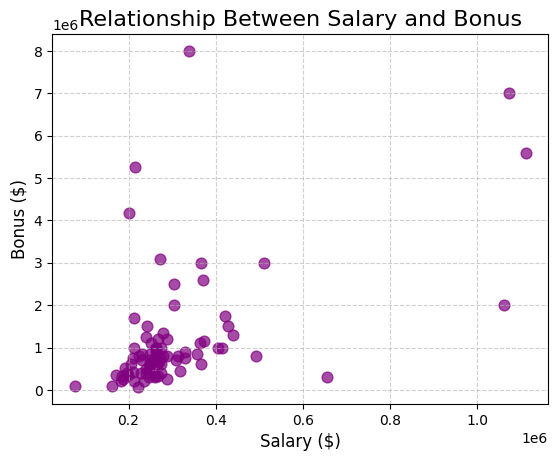

In [12]:
# scatter plot again without the outlier
plt.Figure(figsize=(10, 6))

plt.scatter(df['salary'], df['bonus'], 
            color='purple',
            alpha=0.7,
            s=60)

plt.title('Relationship Between Salary and Bonus', fontsize=16)
plt.xlabel('Salary ($)', fontsize=12)
plt.ylabel('Bonus ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

We would argue that there’s 4 more outliers to investigate; let's look at a couple of them. Two people made bonuses of at least 5 million dollars, and a salary of over 1 million dollars; in other words, they made out like bandits. 

**What are the names associated with those points**

In [13]:
# identify other outliers that have bonus > 5 million and salary > 1 million
df[(df['bonus'] > 5e6) & (df['salary'] > 1e6)]

,salary,to_messages,deferral_payments,total_payments,loan_advances,bonus,email_address,restricted_stock_deferred,deferred_income,total_stock_value,...,from_poi_to_this_person,exercised_stock_options,from_messages,other,from_this_person_to_poi,poi,long_term_incentive,shared_receipt_with_poi,restricted_stock,director_fees
LAY KENNETH L,1072321.0,4273.0,202911.0,103559793.0,81525000.0,7000000.0,kenneth.lay@enron.com,NaN,-300000.0,49110078.0,...,123.0,34348384.0,36.0,10359729.0,16.0,True,3600000.0,2411.0,14761694.0,NaN
SKILLING JEFFREY K,1111258.0,3627.0,NaN,8682716.0,NaN,5600000.0,jeff.skilling@enron.com,NaN,NaN,26093672.0,...,88.0,19250000.0,108.0,22122.0,30.0,True,1920000.0,2042.0,6843672.0,NaN


**Would you guess that these are typos or weird spreadsheet lines that we should remove, or that there’s a meaningful reason why these points are different? (In other words, should they be removed before we, say, try to build a POI identifier?)**

In [14]:
print("leave them in, they're valid data points")

leave them in, they're valid data points
